In [1]:
import os
from typing import Dict, List, Literal, Tuple, Optional
import logging
import math

from catboost import CatBoostRegressor
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from pycatch22 import catch22_all
from scipy.interpolate import PchipInterpolator
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from forecasting_module import TimeGPTForecaster, SARIMAXForecaster
from utils import ForecastUtils

from lstm_network import LSTMModel, LSTMTrainer

import autoencoders as ae
import train_autoencoders as train_ae

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Using device: cpu
Using device: cpu


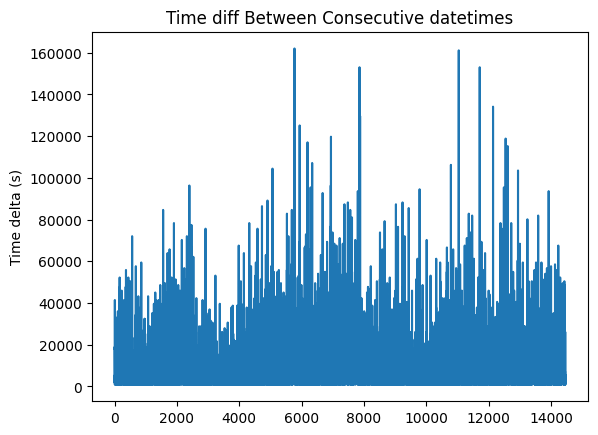

In [ ]:
def plot_time_deltas(df: pd.DataFrame, time_col: str) -> None:
    """Calculate time diff between consecutive datetime entries in the specified column,
    and plot these time deltas"""
    df[time_col]= pd.to_datetime(df[time_col])
    diffs       = df[time_col].diff().dropna()
    plt.plot(diffs.dt.total_seconds())
    plt.ylabel('Time delta (s)')
    plt.title('Time diff Between Consecutive datetimes')
    plt.show()

datasets = {"GDELT_USA_LAB":      {"path": "Time-IMM/GDELT_USA_LAB",       "time_col": "date_time", "y": ["AvgTone"]},
            # "ClusterTrace_707":   {"path": "Time-IMM/ClusterTrace_707",    "time_col": "date_time", "y": ["cpu", "memory"]},
            "EPA_air_los_angeles":{"path": "Time-IMM/EPA_air_los_angeles", "time_col": "date_time", "y": ["ozone"]},
            "FNSPID_EXPE":        {"path": "Time-IMM/FNSPID_EXPE",         "time_col": "date_time", "y": ["adj close"]},
            # "ILINet":             {"path": "Time-IMM/ILINet",              "time_col": "date_time", "y": ["TOTAL PATIENTS"]},
            "repohealth_facebook":{"path": "Time-IMM/repohealth_facebook", "time_col": "date_time", "y": ["new_issues"]},
            "studentlife_fc7337": {"path": "Time-IMM/studentlife_fc7337",  "time_col": "date_time", "y": ["sleep_duration"]},
            "power_consumption":  {"path": "power_consumption",            "time_col": "Datetime",  "y": ["PowerConsumption_Zone1", "PowerConsumption_Zone2", "PowerConsumption_Zone3"]},
            "appliances_energy":  {"path": "appliances_energy",            "time_col": "date",      "y": ["rv1", "rv2"]}}

desired_dataset= "GDELT_USA_LAB"

df             = pd.read_csv(f"../public_datasets/2D/{datasets[desired_dataset]['path']}.csv")
time_col_name  = datasets[desired_dataset]["time_col"]

"""Pre-processing each dataset"""
try:
    if desired_dataset == "GDELT_USA_LAB":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "ClusterTrace_707":
        pass
    elif desired_dataset == "EPA_air_los_angeles":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "FNSPID_EXPE":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "ILINet":
        df.drop(["record_id"], axis=1, inplace=True)
        df = df.drop_duplicates(subset=['date_time'], keep='first').reset_index(drop=True) #some rows have same time
    elif desired_dataset == "repohealth_facebook":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "studentlife_fc7337":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "power_consumption":
        df.drop(["PowerConsumption_Zone2", "PowerConsumption_Zone3"], axis=1, inplace=True)
    elif desired_dataset == "appliances_energy":
        df.drop(["rv2"], axis=1, inplace=True)
except Exception as e:
    pass

y_cols = [col for col in datasets[desired_dataset]["y"] if col in df.columns]
df = df.fillna(0)

plot_time_deltas(df, time_col_name)


In [ ]:
"""Common pre-processing steps"""

# interpolate irregular timestamps first
time_delta = df[time_col_name].diff().dropna()
if time_delta.nunique() == 1: # timestamps uniform, skip PCHIP
    df_uniform = df.copy()
else:
    freq       = ForecastUtils.infer_dominant_freq(df, time_col_name)
    df_uniform = ForecastUtils.apply_pchip_interpolation(df, time_col_name, freq)

horizon  = ForecastUtils.compute_horizon(len(df_uniform), fixed_points=20, pct=0.01)
n_train  = len(df_uniform) - horizon
df_train = df_uniform.iloc[:n_train].copy()
df_test  = df_uniform.iloc[n_train:].copy()

n_windows     = 5    # windows to create 
horizon       = 10   # prediction horizon for each window
horizon_frac  = 0.01 # frac of ENTIRE series length
min_window_len= 1008 # len of smallest window (1008 is timeGPT default)


In [ ]:
"""TimeGPT"""
NIXTLA_API_KEY = 'nixak-TnuMDCHsSM4hajkuXycqZZrNxwtAIoT9O9H7Q8ZwKl2JuJlazRqIPknwJW1AVHX2yB3yfCAwmAogugqQ'
logging.getLogger("nixtla").setLevel(logging.WARNING)

forecaster = TimeGPTForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols, api_key=NIXTLA_API_KEY)

"""single window evaluation"""
print("==== single window evaluation ====")
forecast_dict, _ = forecaster.forecast_timegpt(df_train, df_test, horizon, use_exogenous_cols=True)
forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

"""Multi-window evaluation"""
print("==== multi window evaluation ====")
use_exogenous_cols=True
windows_list  = ForecastUtils.make_windows(df_uniform, n_windows=n_windows, horizon_len=horizon, 
                                           horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)
all_forecasts, mae_list, sizes = {}, [], []

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train shape {train_df.shape}, test shape {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_timegpt(train_df, test_df, horizon_len=horizon, use_exogenous_cols=use_exogenous_cols)
    all_forecasts[f"window_{i}"] = forecast_dict

    # Compute MAE per window
    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j] # shape = H
        y_pred = forecast_dict[target]
        mae    = mean_absolute_error(y_true, y_pred)
        mae_list.append(mae)
        sizes.append(len(y_true))

# Step 3: compute weighted MAE across windows (horizon = weight)
weighted_mae = sum(MAE * n for MAE, n in zip(mae_list, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(mae_list, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")

# # Plot:
# client.plot(df, forecast_df, time_col=time_col_name, target_col=y_cols[0], level=[80,90])

# show last 2% of the history + all predictions
# n = int(len(df) * 0.02)
# df_tail = df.tail(n)
# forecast_tail = forecast_df[forecast_df[time_col_name] >= df_tail[time_col_name].iloc[0]]
# client.plot(df_tail,forecast_tail,time_col=time_col_name,target_col=y_cols[0],level=[80, 90])


In [ ]:
"""SARIMAX"""
logging.basicConfig(level=logging.INFO)

forecaster = SARIMAXForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols)

print("==== single window evaluation ====")
forecast_dict, y_true_scaled = forecaster.forecast_sarimax(df_train, df_test, horizon, 
                                                           order=(1, 0, 0), seasonal_order=(0, 0, 0, 0))
forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

print("==== multi window evaluation ====")
use_exogenous_cols = False
windows_list = ForecastUtils.make_windows(df_uniform, n_windows=n_windows, horizon_len=horizon, 
                                          horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)
all_forecasts, mae_list, sizes = {}, [], []

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train shape {train_df.shape}, test shape {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_sarimax(train_df, test_df, horizon, order=(1, 0, 0),
                                                               seasonal_order=(0, 0, 0, 0), use_exogenous_cols=use_exogenous_cols)
    all_forecasts[f"window_{i}"] = forecast_dict

    # Compute MAE per window
    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j]
        y_pred = forecast_dict[target]
        mae    = mean_absolute_error(y_true, y_pred)
        mae_list.append(mae)
        sizes.append(len(y_true))

# ---- Weighted MAE ----
weighted_mae = sum(MAE * n for MAE, n in zip(mae_list, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(mae_list, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")


In [ ]:
"""run AE"""

# === Example params ===
input_rows        = 1000
input_cols        = 20
layer1_dim        = 64
layer2_dim        = 32
latent_dim        = 8
dropout_prob      = 0.1
layer_dims        = [input_cols, 64, 32, latent_dim]  # for FlexibleAE
pred_dim          = 0
projection_dim    = 0
batch_size        = 32
epochs            = 100
lr                = 1e-3
weight_decay      = 1e-5
scheduler_patience= 5
# === Dummy dataset ===
x_train      = torch.randn(input_rows, input_cols)
train_loader = DataLoader(list(zip(x_train, x_train)), batch_size=batch_size, shuffle=True)

# === Simple AE ===
# simple_ae   = ae.SimpleAutoencoder(input_cols, layer1_dim, layer2_dim, latent_dim, dropout_prob).to(device)
# optimizer = torch.optim.AdamW(simple_ae.parameters(), lr=lr, weight_decay=weight_decay)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)
trainer   = train_ae.TrainAutoencoder()
# best_loss = trainer.train_autoencoder(device, simple_ae, epochs, train_loader, optimizer, scheduler)
# print("Best training loss (SimpleAE):", best_loss)

# === FlexibleAE example ===
# flexible_ae = ae.FlexibleAutoencoder(layer_dims, pred_dim, dropout_prob, projection_dim, pred_hidden_dim=32, mode="reconstruct").to(device)
# optimizer = torch.optim.AdamW(flexible_ae.parameters(), lr=lr, weight_decay=weight_decay)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)
# best_loss = trainer.train_autoencoder(device, flexible_ae, epochs, train_loader, optimizer, scheduler)
# print(f"Best training loss (FlexibleAE): {best_loss:.3f}")

# === VAE ===
val_loader= DataLoader(list(zip(x_train, x_train)), batch_size=batch_size)  # create validation loader
vae       = ae.VAE(input_cols, hidden_dim=64, latent_dim=latent_dim, dropout_prob=dropout_prob).to(device)
optimizer = torch.optim.AdamW(vae.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)
trainer   = train_ae.TrainVAE()
best_loss = trainer.train_vae(device, vae, epochs, train_loader, optimizer, scheduler, val_loader=val_loader)
print(f"Best training loss (VAE): {best_loss:.3f}")

In [ ]:
"""[real data] Conditional VAE. Train on train set, inference on test set"""

should_we_include_X = True

# === Data parameters ===
batch_size = 32

# === Model parameters ===
hidden_dim = 64
latent_dim = 10
dropout    = 0.05

# === Training parameters ===
epochs              = 100
learning_rate       = 1e-3
weight_decay        = 1e-5
scheduler_patience  = 5
early_stop_patience = 20
save_path           = "best_cvae.pth"

# === Dataset from df (downsample + split) ===
df_small = df.sample(frac=0.1, random_state=42)  # keep 10%
X = df_small.drop(columns=y_cols + [time_col_name], errors="ignore").values
y = df_small[y_cols].values

# === dont use traintestsplit for timeseries (it randomly shuffles, breaking temporal order)
split_idx       = int(len(df_small) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# === Scaling ===
x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train  = x_scaler.fit_transform(X_train)
X_test   = x_scaler.transform(X_test)
y_train  = y_scaler.fit_transform(y_train)
y_test   = y_scaler.transform(y_test)

# === Convert to tensors ===
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)
y_dim   = y_train.shape[1]
x_dim   = X_train.shape[1]

# === Datasets + Loaders ===
train_dataset = TensorDataset(y_train, X_train)
test_dataset  = TensorDataset(y_test, X_test)
train_loader  = DataLoader(train_dataset, batch_size=batch_size, drop_last=True)
val_loader    = DataLoader(test_dataset,  batch_size=batch_size, drop_last=True)

# === Model + Optimizer + Scheduler===
cond_vae  = ae.ConditionalVAE(y_dim=y_dim, x_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim, dropout=dropout).to(device)
optimizer = torch.optim.AdamW(cond_vae.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)

# === Trainer ===
trainer   = train_ae.TrainConditionalVAE()
best_loss = trainer.train_cvae(device=device, cvae=cond_vae, epochs=epochs,train_loader=train_loader, optimizer=optimizer,
                               scheduler=scheduler, val_loader=val_loader, patience=early_stop_patience, save_path=save_path)
print(f"Best validation loss: {best_loss:.4f}")

# === inference ===
cond_vae.load_state_dict(torch.load(save_path))
cond_vae.eval()

# === Full test set prediction ===
batch_size_pred   = 64  # adjust based on memory
all_y_pred_scaled = []

with torch.no_grad():
    for batch in range(0, len(X_test), batch_size_pred):
        x_batch = X_test[batch : batch + batch_size_pred].to(device)
        if not should_we_include_X:
            x_batch = torch.zeros(x_batch.size(0), x_dim).to(device)
        z_batch             = torch.randn(x_batch.size(0), latent_dim).to(device)
        y_batch_pred_scaled = cond_vae.decode(z_batch, x=x_batch)
        all_y_pred_scaled.append(y_batch_pred_scaled.cpu())

# Concatenate all batches + MSE
y_pred_scaled = torch.cat(all_y_pred_scaled, dim=0).numpy()
mse = mean_squared_error(y_test, y_pred_scaled)
mae = mean_absolute_error(y_test, y_pred_scaled)
print(f"Scaled y: test MSE = {mse:.4f}, test MAE = {mae:.4f}")

y_pred      = y_scaler.inverse_transform(y_pred_scaled)
y_true_orig = y_scaler.inverse_transform(y_test.numpy())

plt.plot(y_true_orig, label="True")
plt.plot(y_pred, label="Predicted")
plt.title(f"Cond. VAE ('{desired_dataset}' dataset)")
plt.xlabel("Timestep")
plt.ylabel("y value")
plt.legend()
plt.show()


# NOTE: consider this repo for Conditional VAE (https://github.com/unnir/cVAE/blob/master/cvae.py)
# or https://freedium.cfd/https://medium.com/@sofeikov/implementing-conditional-variational-auto-encoders-cvae-from-scratch-29fcbb8cb08f

In [ ]:
"""ECG dataset"""

from __future__ import annotations
import json
import ast
from pathlib import Path
import wfdb

# class ECGLoader:
#     """Load and process the 'PTB-XL' ECG dataset (https://physionet.org/content/ptb-xl/1.0.3/), including SCP code parsing and label encoding.
#     Attributes:
#         X: 3D array of shape (num_records, num_samples, num_leads), ECG signals.
#         y: 2D array of labels, either multi-hot (multi-class) or code confidences (0-100).
#         fs: Sampling frequency of the signals (Hz).
#         lead_names: List of ECG channel names
#     Parameters:
#         base_dir: Path to PTB-XL dataset.
#         sampling: 'hr' for high-resolution (5000 samples/10s), 'lr' for low-resolution (1000 samples/10s).
#         target: 'multi' for multi-hot labels, 'single' for majority-superclass integer labels.
#         segment_duration_sec: Desired segment length in seconds; signals are cropped or zero-padded.
#         max_records: Optional limit on number of records to load.
#         continuous_target: If True, returns code confidence values (0-100) instead of binary labels."""

#     def __init__(self, base_dir: str | Path):
#         self.base = Path(base_dir)

#     @staticmethod
#     def parse_scp_codes(s: str) -> dict[str, float]:
#         """Parse SCP code string into a dictionary of code → confidence (0–100)."""
#         try:
#             return json.loads(s)
#         except json.JSONDecodeError:
#             return ast.literal_eval(s)

#     @staticmethod
#     def extract_superclasses(scp_codes_str: str, scp_super) -> List[str]:
#         """Return list of diagnostic conditions 'superclasses' present in SCP string."""
#         d = PTBXLLoader.parse_scp_codes(scp_codes_str)
#         present_scps = [k for k, v in d.items() if float(v) > 0]
#         supers = [scp_super[s] for s in present_scps if s in scp_super]
#         return sorted(set(supers))

#     @staticmethod
#     def compute_majority_superclass(scp_codes_str: str, scp_super) -> str | None:
#         """Return the diagnostic conditions 'superclass' with the highest summed confidence."""
#         d = PTBXLLoader.parse_scp_codes(scp_codes_str)
#         agg: Dict[str, float] = {}
#         for k, w in d.items():
#             if k in scp_super:
#                 agg[scp_super[k]] = agg.get(scp_super[k], 0.0) + float(w)
#         return max(agg.items(), key=lambda kv: kv[1])[0] if agg else None

#     @staticmethod
#     def encode_scp_vector(scp_str: str, all_codes: list[str]) -> np.ndarray:
#         """Convert SCP string into a vector of code confidences for all_codes."""
#         d = PTBXLLoader.parse_scp_codes(scp_str)
#         return np.array([d.get(code, 0.0) for code in all_codes], dtype=np.float32)

#     def load_dataset(self, sampling: Literal["hr", "lr"] = "lr",
#                      target: Literal["diagnostic_superclass_multi", "diagnostic_superclass_single"] = "diagnostic_superclass_multi",
#                      segment_duration_sec: float | None = 10.0, max_records: int | None = None,
#                      continuous_target: bool=False) -> Tuple[np.ndarray, np.ndarray, int, List[str]]:
#         """Load PTB-XL ECGs.
#         - sampling: "hr" = high-res signal (500hz), "lr" = low-res signal (100Hz)
#         - target: label (y) format. "multi" = vector of values, "single" = 1 value
#         - segment_duration_sec: desired duration of each ECG segment in s (up to the full record length, typically 10s);
#         signals are truncated if longer or zero-padded if shorter to produce a uniform number of samples per segment
#         - max_records: max # of records to load (otherwise it becomes too big)
#         - continuous_target: if True, we get y labels as raw confidences (0-100) instead of binary values
#         Returns X (signals), y (labels), sampling_rate, leads."""
#         meta      = pd.read_csv(self.base / "ptbxl_database.csv")
#         scp       = pd.read_csv(self.base / "scp_statements.csv", index_col=0)
#         scp_diag  = scp[scp["diagnostic"] == 1].index.tolist()
#         fname_col = "filename_hr" if sampling == "hr" else "filename_lr"
#         meta      = meta[[fname_col, "scp_codes"]].copy()

#         if max_records is not None:
#             meta = meta.iloc[:max_records]

#         scp_super    = scp.loc[scp_diag, "diagnostic_class"].to_dict()
#         classes      = sorted(set(scp_super.values()))
#         class_to_idx = {c: i for i, c in enumerate(classes)}
#         rec_supers: List[List[str]] = meta["scp_codes"].map(
#             lambda s: PTBXLLoader.extract_superclasses(s, scp_super)).tolist()

#         if continuous_target:
#             all_codes = sorted({code for scp_str in meta["scp_codes"] for code in PTBXLLoader.parse_scp_codes(scp_str)})
#             y         = np.stack([PTBXLLoader.encode_scp_vector(s, all_codes) for s in meta["scp_codes"]], axis=0)
#         elif target == "diagnostic_superclass_multi":
#             y = np.zeros((len(rec_supers), len(classes)), dtype=np.float32)
#             for i, supers in enumerate(rec_supers):
#                 for s in supers:
#                     y[i, class_to_idx[s]] = 1.0
#         else:
#             majors = meta["scp_codes"].map(lambda s: PTBXLLoader.compute_majority_superclass(s, scp_super)).tolist()
#             y      = np.array([class_to_idx[m] if m is not None else -1 for m in majors], dtype=np.int64)

#         sample_path   = self.base / meta.iloc[0][fname_col]
#         sig0, fields0 = wfdb.rdsamp(str(sample_path))
#         sampling_rate = int(fields0["fs"])
#         leads         = fields0["sig_name"]
#         target_len    = int(sampling_rate * segment_duration_sec) if segment_duration_sec is not None else None

#         X_list: List[np.ndarray] = []
#         for p in meta[fname_col].tolist():
#             sig, _ = wfdb.rdsamp(str(self.base / p))
#             sig    = sig.astype(np.float32)
#             if segment_duration_sec is not None:
#                 T = sig.shape[0]
#                 if T >= target_len:
#                     sig = sig[:target_len, :]
#                 else:
#                     sig = np.pad(sig, ((0, target_len - T), (0, 0)), mode="constant")
#             X_list.append(sig)
#         X = np.stack(X_list, axis=0)
#         return X, y, sampling_rate, leads


from dataset_loaders import ECGLoader

# Run on dataset
ECG_data_path = "../public_datasets/3D/ptb-xl-1.0.3"
loader        = ECGLoader(ECG_data_path)

X, y, sampling_rate, leads = loader.load_dataset(sampling="lr", target="diagnostic_superclass_multi",
                                                 segment_duration_sec=10.0, max_records=100, continuous_target=True)
print(X.shape)  # (patients, time, leads)
print(y.shape)  # (patients, conditions)
print(f"X size (MB): {X.nbytes / 1024**2:.2f}")
print(f"y size (MB): {y.nbytes / 1024**2:.4f}")


(100, 1000, 12)
(100, 23)
X size (MB): 4.58
y size (MB): 0.0088


In [ ]:
def process_argoverse_parquet(parquet_path: str):
    """Convert Argoverse Parquet scenario to X (3D) and y (2D)
    Explicitly follows these rules:
        1. track_id != focal_track_id AND observed = true → include in X
        2. track_id = focal_track_id AND observed = true → include in X
        3. track_id = focal_track_id AND observed = false → include in y only
        4. track_id != focal_track_id AND observed = false → ignore"""
    df = pd.read_parquet(parquet_path)
    
    focal_id = df['focal_track_id'].iloc[0]

    # Explicitly remove irrelevant rows (rule 4)
    df = df[(df['observed'] == True) | (df['track_id'] == focal_id)]

    X_list = []
    y_list = []

    for track_id, track_data in df.groupby('track_id'):
        positions = track_data[['position_x', 'position_y']].values
        headings = track_data['heading'].values
        velocities = track_data[['velocity_x', 'velocity_y']].values
        observed = track_data['observed'].values

        past = []
        future = []

        for t, obs in enumerate(observed):
            if obs:  # observed = True → goes into X
                past.append([
                    positions[t][0],
                    positions[t][1],
                    headings[t],
                    velocities[t][0],
                    velocities[t][1]
                ])
            elif track_id == focal_id:  # observed = False and focal → goes into y
                future.append(positions[t])  # only x, y
        if past:
            X_list.append(np.array(past))
        if future and track_id == focal_id:
            y_list = np.array(future)

    # pad sequences to longest agent
    max_len  = max(len(p) for p in X_list)
    X_padded = np.array([np.pad(p, ((0, max_len-len(p)), (0,0)), 'constant') for p in X_list])

    return X_padded, np.array(y_list)

# Example usage:
argoverse_data_path = "../public_datasets/3D/argoverse_forecasting"
folder_name = "00a0ec58-1fb9-4a2b-bfd7-f4e5da7a9eff"
file_name   = "scenario_00a0ec58-1fb9-4a2b-bfd7-f4e5da7a9eff.parquet"
X, y = process_argoverse_parquet(f"{argoverse_data_path}/{folder_name}/{file_name}")
print(X.shape, y.shape)


(48, 50, 5) (60, 2)


array([[[ 3.75754480e+03,  1.51315538e+03, -5.05963571e-01,
          8.00165443e+00, -4.41989427e+00],
        [ 3.75787330e+03,  1.51297149e+03, -5.05847990e-01,
          8.00165443e+00, -4.41989427e+00],
        [ 3.75829972e+03,  1.51273127e+03, -5.06055413e-01,
          8.01717960e+00, -4.42891275e+00],
        ...,
        [ 3.79633976e+03,  1.49101453e+03, -5.11001861e-01,
          8.58688147e+00, -4.84937238e+00],
        [ 3.79720352e+03,  1.49054462e+03, -5.09666971e-01,
          8.59090637e+00, -4.82813894e+00],
        [ 3.79806688e+03,  1.49007194e+03, -5.09403966e-01,
          8.60591433e+00, -4.79682109e+00]],

       [[ 3.81454969e+03,  1.48066481e+03, -5.03265000e-01,
          8.96041797e+00, -4.97248361e+00],
        [ 3.81501317e+03,  1.48040792e+03, -5.03259672e-01,
          8.97371785e+00, -4.97096682e+00],
        [ 3.81558797e+03,  1.48008630e+03, -5.03484853e-01,
          8.98589507e+00, -4.96467780e+00],
        ...,
        [ 3.85572011e+03,  1.4572017

In [ ]:
"""Multistep LSTM predictor"""
import torch.optim as optim
from forecasting_module import BaseForecaster

class FlexibleLSTM(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int, output_dim: int):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # last step only

class FlexibleLSTMTrainer:
    def __init__(self, model, lr=1e-3, epochs=30, device="cpu"):
        self.model = model.to(device)
        self.lr = lr
        self.epochs = epochs
        self.device = device
        self.loss_fn = nn.MSELoss()

    def _make_batches(self, y, X, seq_len, horizon):
        """Convert timeseries to (X_seq, y_future) windows."""
        data = y if X is None else np.concatenate([y, X], axis=1)
        X_batches, y_batches = [], []
        for i in range(len(data) - seq_len - horizon):
            X_batches.append(data[i:i+seq_len])
            y_batches.append(y[i+seq_len:i+seq_len+horizon])
        return (torch.tensor(np.stack(X_batches), dtype=torch.float32),
                torch.tensor(np.stack(y_batches), dtype=torch.float32),)

    def fit(self, y_train, X_train, seq_len, horizon, y_val=None, X_val=None):
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        Xb, yb = self._make_batches(y_train, X_train, seq_len, horizon)
        Xb, yb = Xb.to(self.device), yb.to(self.device)

        for epoch in range(self.epochs):
            self.model.train()
            optimizer.zero_grad()
            preds = self.model(Xb)
            loss  = self.loss_fn(preds, yb[:, -1, :])  # predict horizon last-step
            loss.backward()
            optimizer.step()
            if (epoch+1) % 10 == 0:
                print(f"Epoch {epoch+1}, loss={loss.item():.4f}")

    def predict_seq2seq(self, y_test, X_test, seq_len, horizon):
        Xb, yb = self._make_batches(y_test, X_test, seq_len, horizon)
        self.model.eval()
        with torch.no_grad():
            preds = self.model(Xb.to(self.device)).cpu().numpy()
        return preds

    def predict_autoreg(self, y_test, X_test, seq_len, horizon):
        """Step-by-step forecasting with feedback of predictions."""
        data  = y_test if X_test is None else np.concatenate([y_test, X_test], axis=1)
        preds = []
        self.model.eval()
        with torch.no_grad():
            for i in range(len(data) - seq_len - horizon):
                window = torch.tensor(data[i:i+seq_len], dtype=torch.float32).unsqueeze(0).to(self.device)
                pred   = self.model(window).cpu().numpy()
                preds.append(pred)
                # feed prediction back only into y part (not exogenous)
                data[i+seq_len] = np.concatenate([pred[0], data[i+seq_len, y_test.shape[1]:]])
        return np.array(preds)


class LSTMForecaster(BaseForecaster):
    def __init__(self, df, time_col: str, y_cols: list[str],
                 use_exogenous: bool = False, seq_len: int = 30, horizon: int = 10,
                 hidden_size: int = 64, epochs: int = 30, lr: float = 1e-3):
        super().__init__(df, time_col, y_cols)
        self.use_exogenous = use_exogenous
        self.seq_len = seq_len
        self.horizon = horizon
        self.hidden_size = hidden_size
        self.epochs = epochs
        self.lr = lr

        # Exogenous columns = all columns minus time + y
        if self.use_exogenous:
            self.X_cols = [c for c in df.columns if c not in [time_col] + y_cols]
        else:
            self.X_cols = []

    def _prepare_data(self, df):
        """Return tensors for y (and X if exogenous)."""
        y = df[self.y_cols].values.astype(np.float32)
        if self.use_exogenous and self.X_cols:
            X = df[self.X_cols].values.astype(np.float32)
        else:
            X = None
        return y, X

    def fit(self, df_train, df_val=None):
        y_train, X_train = self._prepare_data(df_train)
        y_val, X_val = (None, None) if df_val is None else self._prepare_data(df_val)

        self.model = FlexibleLSTM(
            input_dim=len(self.y_cols) + (X_train.shape[1] if X_train is not None else 0),
            hidden_size=self.hidden_size,
            output_dim=len(self.y_cols))

        trainer = FlexibleLSTMTrainer(self.model, lr=self.lr, epochs=self.epochs)
        trainer.fit(y_train, X_train, self.seq_len, self.horizon,
                    y_val=y_val, X_val=X_val)
        self.trainer = trainer

    def predict(self, df_test, autoregressive: bool = False):
        y_test, X_test = self._prepare_data(df_test)
        if autoregressive:
            return self.trainer.predict_autoreg(y_test, X_test, self.seq_len, self.horizon)
        else:
            return self.trainer.predict_seq2seq(y_test, X_test, self.seq_len, self.horizon)

    def forecast_lstm(self, train_df, test_df, horizon: int,
                      use_exogenous: bool = True, stepwise: bool = False):
        """Train + forecast like SARIMAX.
        Args:
            train_df, test_df: pandas DataFrames
            horizon: forecast horizon
            use_exogenous: toggle exogenous features
            stepwise: if True → autoregressive, else → direct multi-step
        Returns:
            forecast_dict: {y_col: np.array predictions}
            y_true: true target values (scaled)"""
        # override exogenous toggle for this run
        self.use_exogenous = use_exogenous
        if use_exogenous:
            self.X_cols = [c for c in train_df.columns if c not in [self.time_col] + self.y_cols]
        else:
            self.X_cols = []

        self.fit(train_df)
        preds = self.predict(test_df, autoregressive=stepwise)
        y_true, _ = self._prepare_data(test_df)

        if preds.ndim == 1:
            preds = preds.reshape(-1, 1)

        forecast_dict = {col: preds[:, i] for i, col in enumerate(self.y_cols)}
        self.forecast_dfs = {col: forecast_dict[col] for col in self.y_cols}
        return forecast_dict, y_true


"""LSTM run"""
n_windows = 5
horizon = 10       # prediction steps
seq_len = 30       # past steps
# min_window_len = seq_len + horizon  # ensure each window is long enough

logging.basicConfig(level=logging.INFO)

forecaster = LSTMForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols, seq_len=seq_len)

print("==== single window evaluation ====")
# forecast_dict, y_true_scaled = forecaster.forecast_lstm(
#     df_train, df_test, horizon,
#     use_exogenous=True,   # or False
#     stepwise=False)        # sequence prediction (False) or step-by-step (True)

# forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

print("==== multi window evaluation ====")
all_forecasts, mae_list, sizes = {}, [], []
windows_list = ForecastUtils.make_windows(
    df_uniform, n_windows=n_windows, horizon_len=horizon,
    horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train {train_df.shape}, test {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_lstm(
        train_df, test_df, horizon,
        use_exogenous=True,
        stepwise=True)
    all_forecasts[f"window_{i}"] = forecast_dict

    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j]
        y_pred = forecast_dict[target]
        mae = mean_absolute_error(y_true, y_pred)
        mae_list.append(mae)
        sizes.append(len(y_true))

# ---- Weighted MAE ----
weighted_mae = sum(MAE * n for MAE, n in zip(mae_list, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(mae_list, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")


In [ ]:
"""TimesFM"""
from timesfm import TimesFmHparams, TimesFm, TimesFmCheckpoint

# Hyperparameters
hparams = TimesFmHparams(
    backend="jax",
    per_core_batch_size=32,
    horizon_len=128,
    num_layers=20,
    context_len=512,
    use_positional_embedding=True,)

# Local checkpoint folder containing 'checkpoint'
checkpoint = TimesFmCheckpoint(local_dir="interim_data")

# Initialize model
model = TimesFm(hparams=hparams, checkpoint=checkpoint)

# Load manually (if needed)
# model.load_from_checkpoint("interim_data/checkpoint", checkpoint_type=CheckpointType.FLAX)
model.load_from_checkpoint(repo_id="google/timesfm-1.0-200m")#, checkpoint_type=CheckpointType.FLAX)

# Forecast example
y = np.arange(100)
forecast = model.forecast(y, horizon=10)
print(forecast)


In [ ]:
"""Conditional VAE. Train on train set, inference on test set"""

# === Data parameters ===
n_samples  = 1000
y_dim      = 1
x_dim      = 10  # optional
batch_size = 32

# === Model parameters ===
hidden_dim = 64
latent_dim = 10
dropout    = 0.05

# === Training parameters ===
epochs              = 100
learning_rate       = 1e-3
weight_decay        = 1e-5
scheduler_patience  = 5
early_stop_patience = 10
save_path           = "best_cvae.pth"

# === Dataset ===
y_data  = torch.randn(n_samples, y_dim)
x_data  = torch.randn(n_samples, x_dim)
dataset = TensorDataset(y_data, x_data)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(dataset, batch_size=batch_size)

cond_vae  = ae.ConditionalVAE(y_dim=y_dim, x_dim=x_dim, hidden_dim=hidden_dim,
                              latent_dim=latent_dim, dropout=dropout).to(device)

# === Optimizer + Scheduler ===
optimizer = torch.optim.AdamW(cond_vae.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)

# === Trainer ===
trainer   = train_ae.TrainConditionalVAE()
best_loss = trainer.train_cvae(device=device, cvae=cond_vae, epochs=epochs, train_loader=train_loader, optimizer=optimizer,
                               scheduler=scheduler, val_loader=val_loader, patience=early_stop_patience, save_path=save_path)
print(f"Best validation loss: {best_loss:.4f}")

# === Load best model for inference ===
cond_vae.load_state_dict(torch.load(save_path))
cond_vae.eval()

# === Example inference ===
n_rows_gen   = 5
z_sample     = torch.randn(n_rows_gen, latent_dim).to(device)
is_x_present = True
if is_x_present:
    x_sample = torch.randn(n_rows_gen, x_dim).to(device)
else:
    x_sample = torch.zeros(n_rows_gen, x_dim).to(device)

y_sample = cond_vae.decode(z_sample, x=x_sample)
print(f"Generated y sample: {y_sample}")


In [ ]:
"""Applying metrics on X vs z"""

# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # Split your original data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Encode train/test via VAE
# z_train = vae.encoder.predict(X_train)  # shape (num_samples, latent_dim)
# z_test  = vae.encoder.predict(X_test)

# # --- Predictor on raw X ---
# model_X = LinearRegression()
# model_X.fit(X_train.reshape(X_train.shape[0], -1), y_train)  # flatten if needed
# y_pred_X = model_X.predict(X_test.reshape(X_test.shape[0], -1))

# # --- Predictor on latent z ---
# model_z = LinearRegression()
# model_z.fit(z_train, y_train)
# y_pred_z = model_z.predict(z_test)

# # --- Metrics ---
# def print_metrics(y_true, y_pred, name):
#     mse = mean_squared_error(y_true, y_pred)
#     mae = mean_absolute_error(y_true, y_pred)
#     r2  = r2_score(y_true, y_pred)
#     print(f"{name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# print_metrics(y_test, y_pred_X, "Predictor on X")
# print_metrics(y_test, y_pred_z, "Predictor on z")


In [ ]:
from downsampling import LTTBDownsampler, OtherDownsamplers

def df_plotter(df, df_downsampled, col_to_plot: int, time_col: str) -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(df[time_col], df.iloc[:, col_to_plot], alpha=0.8, linewidth=2)
    plt.plot(df_downsampled[time_col], df_downsampled.iloc[:, col_to_plot], alpha=0.8, linewidth=1)
    plt.legend(['Original', 'Downsampled'])
    plt.tight_layout()
    plt.show()

def _add_time_features(df: pd.DataFrame, y_col: str, time_col: str = 'Datetime', lag_amount: int = 1, rolling_window: int = 3) -> pd.DataFrame:
    df = df.copy()
    df.loc[:, 'hour']      = df[time_col].dt.hour
    df.loc[:, 'dayofweek'] = df[time_col].dt.dayofweek
    df.loc[:, f'lag_{lag_amount}'] = df[y_col].shift(lag_amount)
    df.loc[:, f'rolling_mean_{rolling_window}'] = df[y_col].rolling(rolling_window).mean()
    return df.dropna()


class SplitterScaler:
    @staticmethod
    def split_X_and_y(df, time_col: str, y) -> tuple:
        X = df.drop([time_col]+ y, axis=1)
        y = df[y]
        return X, y
        # y1= df[['PowerConsumption_Zone1']]
        # y2= df[['PowerConsumption_Zone2']]
        # y3= df[['PowerConsumption_Zone3']]
        # return X, y, y1, y2, y3

    @staticmethod
    def traintest_split_then_scale(X: pd.DataFrame, y: pd.Series) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        scaler_X       = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled  = scaler_X.transform(X_test)

        scaler_y       = StandardScaler()
        y_train_scaled = scaler_y.fit_transform(y_train)
        y_test_scaled  = scaler_y.transform(y_test)
        return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler_y

    @staticmethod
    def scale_X_and_y(X: pd.DataFrame, y: pd.DataFrame):
        """Scale features X and target y using StandardScaler.
        Returns scaled arrays and fitted scalers"""
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)
        return X_scaled, y_scaled, (scaler_X, scaler_y)

    @staticmethod
    def scale_X_and_y_latents(X_train: pd.DataFrame | np.ndarray, X_valid: pd.DataFrame | np.ndarray,
                            y_train: pd.DataFrame | np.ndarray, y_valid: pd.DataFrame | np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler, StandardScaler]:
        """Fit scalers on X_train and y_train, transform both train and valid sets.
        Returns scaled X_train, X_valid, y_train, y_valid, scaler_X, scaler_y"""
        scaler_X  = StandardScaler().fit(X_train)
        X_train_s = scaler_X.transform(X_train)
        X_valid_s = scaler_X.transform(X_valid)

        y_train   = np.asarray(y_train).reshape(-1, 1)
        y_valid   = np.asarray(y_valid).reshape(-1, 1)
        scaler_y  = StandardScaler().fit(y_train)
        y_train_s = scaler_y.transform(y_train)
        y_valid_s = scaler_y.transform(y_valid)

        return X_train_s, X_valid_s, y_train_s, y_valid_s, scaler_X, scaler_y


class TrainerAndEvaluator:

    @staticmethod
    def train_catboost_model(X_train_scaled, y_train_scaled):
        model = CatBoostRegressor(iterations=1300, depth=8, learning_rate=0.15, l2_leaf_reg=2, loss_function='RMSE',
                                  random_seed=42, verbose=0, early_stopping_rounds=100, task_type='CPU', bagging_temperature=3)
        model.fit(X_train_scaled, y_train_scaled.ravel())
        return model

    @staticmethod
    def train_and_evaluate_model(train_df: Optional[pd.DataFrame] = None, test_df: Optional[pd.DataFrame] = None,
                                 X_train: Optional[np.ndarray] = None, X_test: Optional[np.ndarray] = None,
                                 y_train: Optional[np.ndarray] = None, y_test: Optional[np.ndarray] = None,
                                 scaler_X: Optional[StandardScaler] = None) -> Tuple[float, float]:
        """Train and evaluate CatBoost. If X/y provided, use them directly.
        Otherwise, extract features from train_df/test_df"""
        
        if X_train is None or y_train is None:
            # Mode 1: from DataFrames
            X, y = SplitterScaler.split_X_and_y(train_df, time_col_name, y_cols)
            X_train_s, X_test_s, y_train_s, y_test_s, _ = SplitterScaler.traintest_split_then_scale(X, y)
        else:
            # Mode 2: from arrays
            if scaler_X:
                X_train_s = scaler_X.transform(X_train)
                X_test_s  = scaler_X.transform(X_test)
            else:
                X_train_s, X_test_s = X_train, X_test  # already scaled
            y_train_s, y_test_s = y_train, y_test

        model  = TrainerAndEvaluator.train_catboost_model(X_train_s, y_train_s)
        y_pred = model.predict(X_test_s)

        # --- metrics ---
        if y_test_s.ndim == 1 or y_test_s.shape[1] == 1:
            rmse  = float(np.sqrt(mean_squared_error(y_test_s, y_pred)))
            nrmse = float(rmse / (y_test_s.max() - y_test_s.min()))
        else:
            rmses = [np.sqrt(mean_squared_error(y_test_s[:, i], y_pred[:, i]))
                     for i in range(y_test_s.shape[1])]
            rmse  = float(np.mean(rmses))
            nrmse = float(np.mean([
                r / (y_test_s[:, i].max() - y_test_s[:, i].min())
                for i, r in enumerate(rmses)]))
        return rmse, nrmse

def downsample_and_evaluate(df, new_points_per_col, compression_ratio_list, rmse_list, nrmse_list, method, rdp_epsilon=0.1):
    """Downsample df, evaluate model on original and compressed, store metrics."""
    if method == "union_lttb":
        df_downsampled = LTTBDownsampler.downsample_using_lttb_union(df, time_col=time_col_name, max_points_per_col=new_points_per_col)
    elif method == "intersection_lttb":
        df_downsampled = LTTBDownsampler.downsample_using_lttb_intersection(df, time_col=time_col_name, max_points_per_col=new_points_per_col)
    elif method == "union_lttb_with_spikes":
        df_downsampled = LTTBDownsampler.downsample_lttb_union_with_spikes(df, time_col=time_col_name, max_points_per_col=new_points_per_col,\
                                                                           spike_thresh=4, spike_method='mad')
    elif method == "union_rdp":
        df_downsampled = OtherDownsamplers.downsample_using_rdp_union(df, time_col=time_col_name, epsilon=rdp_epsilon)
    else:
        raise ValueError(f"Unknown downsampling method: {method}")

    rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(df)
    # print(f"orig. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

    compression_ratio = len(df) / len(df_downsampled)
    # print(f"data compressed {compression_ratio:.2f}x")
    rmse_c, nrmse_c = TrainerAndEvaluator.train_and_evaluate_model(df_downsampled)
    # print(f"compress. RMSE: {rmse_c:.3f}, norm RMSE: {nrmse_c:.3%}")

    compression_ratio_list.append(compression_ratio)
    rmse_list.append(rmse_c)
    nrmse_list.append(nrmse_c)
    return compression_ratio_list, rmse_list, nrmse_list


In [ ]:
"""timeVAE preprocessing (windowing)"""

def create_windows(data: np.ndarray, window_size: int, step_size: int) -> np.ndarray:
    N      = (data.shape[0] - window_size) // step_size + 1
    windows= np.array([data[i*step_size:i*step_size+window_size] for i in range(N)])
    return windows

X_raw    = df.drop(columns=[time_col_name] + y_cols).values
y_raw    = df[y_cols].values

# scale + Transform
scaler_X = StandardScaler().fit(X_raw)
scaler_y = StandardScaler().fit(y_raw)
X_scaled = scaler_X.transform(X_raw)
y_scaled = scaler_y.transform(y_raw)

window_size = 20
step_size   = window_size // 4
X_windows   = create_windows(X_scaled, window_size, step_size)
y_windows   = create_windows(y_scaled, window_size, step_size)

print("X_win shape:", X_windows.shape, "y_win shape:", y_windows.shape)

# Save to ./data/ + timeVAE repo
should_we_save_in_timeVAE = True
if should_we_save_in_timeVAE:
    os.makedirs('../interim_data', exist_ok=True)
    np.savez_compressed(f"../interim_data/{desired_dataset}.npz", data=np.array(X_windows, dtype=np.float32))
    # np.savez_compressed(f"../interim_data/{desired_dataset}.npz", data=X_windows, target=y_windows)
    np.savez_compressed(f"../../timeVAE/data/{desired_dataset}.npz", data=np.array(X_windows, dtype=np.float32))
print(f"saved {desired_dataset} info to ../interim_data/{desired_dataset}.npz")


In [ ]:
"""predicting y on latents z"""
z_train = np.load(f"../interim_data/z_train_{desired_dataset}.npy")
z_valid = np.load(f"../interim_data/z_valid_{desired_dataset}.npy")
print(f"z_train shape: {z_train.shape}, z_valid shape: {z_valid.shape}")

y_squeezed = y_windows[:, -1, 0].reshape(-1, 1)

# y train/valid shaped like z_train/valid
n_train = z_train.shape[0]
n_valid = z_valid.shape[0]
y_train = y_squeezed[:n_train]
y_valid = y_squeezed[n_train:n_train + n_valid]

print("y_train/y_valid shapes:", y_train.shape, y_valid.shape)

# z_train_df = pd.DataFrame(z_train, columns=[f"z{i}" for i in range(z_train.shape[1])])
# z_valid_df = pd.DataFrame(z_valid, columns=[f"z{i}" for i in range(z_valid.shape[1])])

rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(X_train=z_train, X_test=z_valid,
                                                           y_train=y_train, y_test=y_valid)
print(f"RMSE: {rmse:.4f}, NRMSE: {nrmse:.4f}")


In [ ]:
"""catch22"""

def catch22_features_from_windows(X_windows: np.ndarray, y_windows: np.ndarray, which_y: str) -> tuple[np.ndarray, np.ndarray]:
    """Apply catch22 to each window/channel and return (features, targets).
    X_windows: shape (n_windows, window_size, n_channels)
    y_windows: shape (n_windows, window_size, n_targets)"""
    
    n_windows, _, n_channels = X_windows.shape
    feats = np.empty((n_windows, n_channels * 22), dtype=float)
    
    for i in range(n_windows):
        channel_feats = [catch22_all(X_windows[i, :, ch])['values']
                         for ch in range(n_channels)]
        feats[i] = np.concatenate(channel_feats)
    
    # Take last value in each target window
    if which_y == "last":
        y_out = y_windows[:, -1, :]
    elif which_y == "mean":
        y_out = np.mean(y_windows, axis=1)
    return feats, y_out

X_c22, y_c22 = catch22_features_from_windows(X_windows, y_windows, which_y="last")
X_train, X_test, y_train, y_test = train_test_split(X_c22, y_c22, test_size=0.2, random_state=42)
print(f"shapes: X_train {X_train.shape}, X_test {X_test.shape}, y_train {y_train.shape}, y_test {y_test.shape}")

# X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, _ = SplitterScaler.traintest_split_then_scale(X_c22, y_c22)

if y_train.shape[1] == 1:
    rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(X_train=X_train, X_test=X_test,
                                                               y_train=y_train.ravel(), y_test=y_test.ravel())
    print(f"Train RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")
else:
    rmses   = []
    nrmse_s = []
    for i in range(y_train.shape[1]):
        rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(
            X_train=X_train,
            X_test=X_test,
            y_train=y_train[:, i],
            y_test=y_test[:, i])
        rmses.append(rmse)
        nrmse_s.append(nrmse)
    print("Mean RMSE:", np.mean(rmses))
    print("Mean NRMSE:", np.mean(nrmse_s))


In [ ]:
"""Evaluate downsampling methods"""
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=False)
rmse, nrmse       = TrainerAndEvaluator.train_and_evaluate_model(df_train, df_test)
print(f"Original train RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

N_VW   = 10

N_LTTB = 2
spike_method      = 'zscore' # 'zscore' or 'mad'
spike_method_thres= 3

rdp_epsilon       = 1
subsampling_ratio = 100
N_last_rows       = 100

lttb_union_train = LTTBDownsampler.downsample_using_lttb_union(df_train, time_col=time_col_name,
                                                               max_points_per_col=len(df_train) // N_LTTB)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_union_train, df_test)
print(f"LTTB union ({N_LTTB=})")
print(f"data compressed {len(df_train)/len(lttb_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

lttb_intersect_train = LTTBDownsampler.downsample_using_lttb_intersection(df_train, time_col=time_col_name,
                                                                          max_points_per_col=len(df_train) // N_LTTB)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_intersect_train, df_test)
print("LTTB intersection")
print(f"data compressed {len(df_train)/len(lttb_intersect_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

lttb_union_spikes_train = LTTBDownsampler.downsample_lttb_union_with_spikes(df_train, time_col=time_col_name,
                                                                            max_points_per_col=len(df_train) // N_LTTB,
                                                                            spike_thresh=spike_method_thres, spike_method=spike_method)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_union_spikes_train, df_test)
print(f"LTTB union +spikes ({spike_method=})")
print(f"data compressed {len(df_train)/len(lttb_union_spikes_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

rdp_union_train = OtherDownsamplers.downsample_using_rdp_union(df_train, time_col=time_col_name, epsilon=rdp_epsilon)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(rdp_union_train, df_test)
print(f"RDP union ({rdp_epsilon=})")
print(f"data compressed {len(df_train)/len(rdp_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

vw_union_train = OtherDownsamplers.downsample_using_vw_union(df_train, time_col=time_col_name, target_points=len(df_train) // N_VW)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(vw_union_train, df_test)
print(f"VW union ({N_VW=})")
print(f"data compressed {len(df_train)/len(vw_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

subsample_train = OtherDownsamplers.subsample_timeseries(df_train, subsampling_ratio=subsampling_ratio)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(subsample_train, df_test)
print(f"Subsample ({subsampling_ratio=})")
print(f"data compressed {len(df_train)/len(subsample_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

last_N_rows_train = OtherDownsamplers.get_last_N_rows(df_train, N_rows=N_last_rows)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(last_N_rows_train, df_test)
print(f"Last N rows ({N_last_rows=})")
print(f"data compressed {len(df_train)/len(last_N_rows_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

# df_plotter(df, lttb_union_train, 1, time_col_name)

In [ ]:
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

def plot_corr_matrix(df: pd.DataFrame, title: str = "Feature Correlation Matrix") -> None:
    """Plot heatmap of Pearson correlation matrix for the DataFrame features"""
    corr = df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_autocorr(series: pd.Series, lags: int = 40, title: str = None) -> None:
    """Plot autocorrelation function (ACF) for a pandas Series"""
    plt.figure(figsize=(8, 4))
    plot_acf(series.dropna(), lags=lags, alpha=0.05)
    plt.title(title or f"Autocorrelation (up to {lags} lags)")
    plt.tight_layout()
    plt.show()

# plot_corr_matrix(df)
# plot_corr_matrix(df_downsampled)
# plot_corr_matrix(df_downsampled2)

plot_autocorr(df['act_still'], lags=10)
plot_autocorr(df_downsampled['act_still'], lags=10)
plot_autocorr(df_downsampled2['act_still'], lags=10)

In [ ]:
"""LSTM"""
# ===== Example usage =====
n_samples  = 100
n_rows     = 10
n_features = 15
X = torch.randn(n_samples, n_rows, n_features)
y = torch.randn(n_samples, 1)

# Train/val split
train_size = 80
train_X, val_X = X[:train_size], X[train_size:]
train_y, val_y = y[:train_size], y[train_size:]

# Model/optimizer/loss
model     = LSTMModel(input_size=n_features, hidden_size=64, num_layers=2, output_size=1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Train
trainer = LSTMTrainer(model, optimizer, criterion)
trainer.fit(train_X, train_y, val_X, val_y, epochs=300)

# Inference
new_seq    = torch.randn(1, n_rows, n_features)  # batch=1, seq=10, features=15
prediction = trainer.predict(new_seq)
print("Prediction:", prediction)


In [ ]:
"""Seq2seq LSTM"""

import torch
import torch.nn as nn

class Seq2SeqLSTM(nn.Module):
    """
    Encoder-decoder LSTM for multi-step forecasting.
    Auto-regressive: generates one step at a time.
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size, device='cpu'):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.device = device

        # Encoder LSTM
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # Decoder LSTM (one step at a time)
        self.decoder = nn.LSTM(output_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_input, horizon):
        """
        encoder_input: (batch, seq_len, input_size)
        horizon: number of future steps to predict
        returns: (batch, horizon, output_size)
        """
        batch_size = encoder_input.size(0)
        # Encode
        _, (h, c) = self.encoder(encoder_input)

        # Initialize decoder input as last step of encoder
        decoder_input = encoder_input[:, -1:, :]  # shape: (batch, 1, input_size)
        outputs = []

        for t in range(horizon):
            out, (h, c) = self.decoder(decoder_input, (h, c))
            step_pred = self.fc(out)  # (batch, 1, output_size)
            outputs.append(step_pred)
            decoder_input = step_pred  # feed prediction as next input

        return torch.cat(outputs, dim=1)  # (batch, horizon, output_size)

# toy data
batch_size, seq_len, n_features = 4, 10, 3
horizon = 5
X = torch.randn(batch_size, seq_len, n_features)

model = Seq2SeqLSTM(input_size=n_features, hidden_size=32, num_layers=1, output_size=n_features)
preds = model(X, horizon)  # shape: (batch, horizon, n_features)
print(preds.shape)


In [ ]:
"""Make scatterplot of compressions vs rmse"""
compression_ratio_list, rmse_list, nrmse_list = [], [], []
new_points_per_col_ratio = list(range(2, 10, 8))
new_points_per_col = [int(len(df) / ratio) for ratio in new_points_per_col_ratio]

for i, point_n in enumerate(new_points_per_col):
    compression_ratio_list, rmse_list, nrmse_list = downsample_and_evaluate(
        df, point_n, compression_ratio_list, rmse_list, nrmse_list, rdp_epsilon=0.1, method="union_rdp")

rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(df)

plt.figure(figsize=(8, 5))
# plt.scatter(compression_ratio_list, nrmse_list, label="Norm. RMSE", marker="o")
# plt.scatter(1, nrmse, label="original")

plt.scatter(compression_ratio_list, rmse_list, label="RMSE", marker="x")
plt.scatter(1, rmse, label="original")

plt.xlabel("Compression Ratio")
plt.ylabel("RMS error")
plt.title("Error vs Compression Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# """Choose good epsilon for RDP"""
# for col in df.columns:
#     if col == time_col_name:
#         continue
#     if pd.api.types.is_datetime64_any_dtype(df[time_col_name]):
#         x_vals = df[time_col_name].astype("int64")
#     else:
#         x_vals = df[time_col_name].values

#     coords = np.column_stack((x_vals, df[col].values))
#     eps1 = OtherDownsamplers.choose_rdp_epsilon(coords, method="mad", factor=1.0)
#     eps2 = OtherDownsamplers.choose_rdp_epsilon(coords, method="std", factor=1.0)
#     eps3 = OtherDownsamplers.choose_rdp_epsilon(coords, method="fraction", factor=1e-3)

#     print(f"RDP epsilon (mad): {eps1:.3f}, (std): {eps2:.3f}, (fraction): {eps3:.3f}")